In [7]:
import sys
# !{sys.executable} -m pip install "umap-learn>=0.5.7" "scikit-learn>=1.5,<1.8" -q
# print("Done -- restart the kernel before running the next cells.")


In [8]:
# ── Output directory ────────────────────────────────────────────────
# All plots, CSVs, and JSON files are saved here (created automatically).
OUTPUT_DIR = "results_full_dataset"
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output folder: {OUTPUT_DIR}/")

Output folder: results_full_dataset/


In [9]:
import sys, os, time, warnings
warnings.filterwarnings('ignore')

_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if _root not in sys.path:
    sys.path.insert(0, _root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.manifold import trustworthiness
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              roc_auc_score, pairwise_distances)
from scipy.stats import spearmanr
import umap

import metric_functions as mf
if not hasattr(mf, 'ai_projection_mean_stable'):
    mf.ai_projection_mean_stable = mf.ai_projection_mean

from metric_functions import (
    stack_npp_to_ppn,
    compute_mean_projection,
    project_stack_to_tangent_features,
    compute_pairwise_distance_matrix,
)

DATA_DIR = "."
data = np.load(os.path.join(DATA_DIR, "covariance_matrices.npz"), allow_pickle=True)
X = data["X"]
y = data["y"]
meta = pd.read_csv(os.path.join(DATA_DIR, "metadata.csv"))

# All subsets defined for reference
idx_small = ((meta["sample"] == "sample_a") & (meta["scale"].isin([2, 6, 10]))).values
X_small, y_small = X[idx_small], y[idx_small]

idx_a = (meta["sample"] == "sample_a").values
X_a, y_a = X[idx_a], y[idx_a]

idx_ab = meta["sample"].isin(["sample_a", "sample_b"]).values
X_ab, y_ab = X[idx_ab], y[idx_ab]

X_full, y_full = X, y

print(f"X shape : {X.shape}")
print(f"Classes : {np.unique(y).tolist()}")
print(f"\nSubset sizes -- small:{len(y_small)}  sample_a:{len(y_a)}  "
      f"ab:{len(y_ab)}  full:{len(y_full)}")

METRICS     = ["bw", "ai", "loge"]
UMAP_PARAMS = dict(n_neighbors=15, min_dist=0.1, random_state=42)

X shape : (4752, 22, 22)
Classes : ['aluminium_foil', 'brown_bread', 'corduroy', 'cork', 'cotton', 'cracker', 'lettuce_leaf', 'linen', 'white_bread', 'wood', 'wool']

Subset sizes -- small:396  sample_a:1188  ab:2376  full:4752


## Task 1 — Manifold UMAP vs Tangent-Space UMAP

- **Manifold UMAP** uses `X_small` (n=396) — pairwise SPD distances are O(n²) so the full dataset is impractical here.
- **Tangent-Space UMAP** uses `X_ab` (n=864) for a richer structural view without the O(n²) cost.

Metrics (neighborhood overlap, trustworthiness, Spearman ρ) are computed on `X_small` where both manifold and tangent embeddings are available.

In [10]:
# =============================================================================
# TASK 1 -- Manifold UMAP vs Tangent-Space UMAP
# =============================================================================
# Pairwise SPD distances are O(n^2).  Manifold UMAP uses X_small (n=396) for
# tractability.  Tangent-space UMAP is shown on X_ab (n=864) to give a richer
# picture of the full data's structure.

results_t1 = {}

for metric in METRICS:
    print(f"\n{'='*52}\n  {metric.upper()} geometry\n{'='*52}")

    # A. Manifold UMAP on X_small (n=396) ------------------------------------
    print("  [A] Pairwise distances on X_small ...", flush=True)
    D = compute_pairwise_distance_matrix(X_small, metric=metric, verbose=False)
    print(f"      D shape={D.shape}  max={D.max():.4f}")
    print("  [A] UMAP(metric='precomputed') ...", flush=True)
    emb_manifold = umap.UMAP(metric="precomputed", **UMAP_PARAMS).fit_transform(D)

    # B. Tangent-space UMAP on X_ab (n=864) ----------------------------------
    print("  [B] Barycenter on X_ab ...", flush=True)
    X_ppn_ab  = stack_npp_to_ppn(X_ab)
    M, info   = compute_mean_projection(X_ppn_ab, metric=metric)
    print(f"      converged: iters={info['iters']}  final_dist={info['final']:.2e}")

    print("  [B] Tangent projection on X_ab ...", flush=True)
    Z_ab = project_stack_to_tangent_features(X_ab, M, metric=metric)
    print(f"      Z_ab shape={Z_ab.shape}")

    print("  [B] UMAP(metric='euclidean') on X_ab ...", flush=True)
    emb_tangent = umap.UMAP(metric="euclidean", **UMAP_PARAMS).fit_transform(Z_ab)

    # Also store small-set tangent vectors for Task 1 metrics
    Z_small = project_stack_to_tangent_features(X_small,
                  results_t1[metric]["M"] if metric in results_t1 else M,
                  metric=metric)

    results_t1[metric] = {
        "D": D, "M": M,
        "Z_small": project_stack_to_tangent_features(X_small, M, metric=metric),
        "Z_ab": Z_ab,
        "emb_manifold": emb_manifold,   # X_small manifold UMAP
        "emb_tangent":  emb_tangent,    # X_ab tangent UMAP
    }
    print("  Done.")

print("\n\u2713  Task 1 computations complete.")



  BW geometry
  [A] Pairwise distances on X_small ...
      D shape=(396, 396)  max=2.5277
  [A] UMAP(metric='precomputed') ...
  [B] Barycenter on X_ab ...
      converged: iters=500  final_dist=6.60e-03
  [B] Tangent projection on X_ab ...
      Z_ab shape=(2376, 253)
  [B] UMAP(metric='euclidean') on X_ab ...
  Done.

  AI geometry
  [A] Pairwise distances on X_small ...
      D shape=(396, 396)  max=16.2767
  [A] UMAP(metric='precomputed') ...
  [B] Barycenter on X_ab ...
      converged: iters=48  final_dist=1.99e+00
  [B] Tangent projection on X_ab ...
      Z_ab shape=(2376, 253)
  [B] UMAP(metric='euclidean') on X_ab ...
  Done.

  LOGE geometry
  [A] Pairwise distances on X_small ...
      D shape=(396, 396)  max=8.9764
  [A] UMAP(metric='precomputed') ...
  [B] Barycenter on X_ab ...
      converged: iters=0  final_dist=0.00e+00
  [B] Tangent projection on X_ab ...
      Z_ab shape=(2376, 253)
  [B] UMAP(metric='euclidean') on X_ab ...
  Done.

✓  Task 1 computations complet

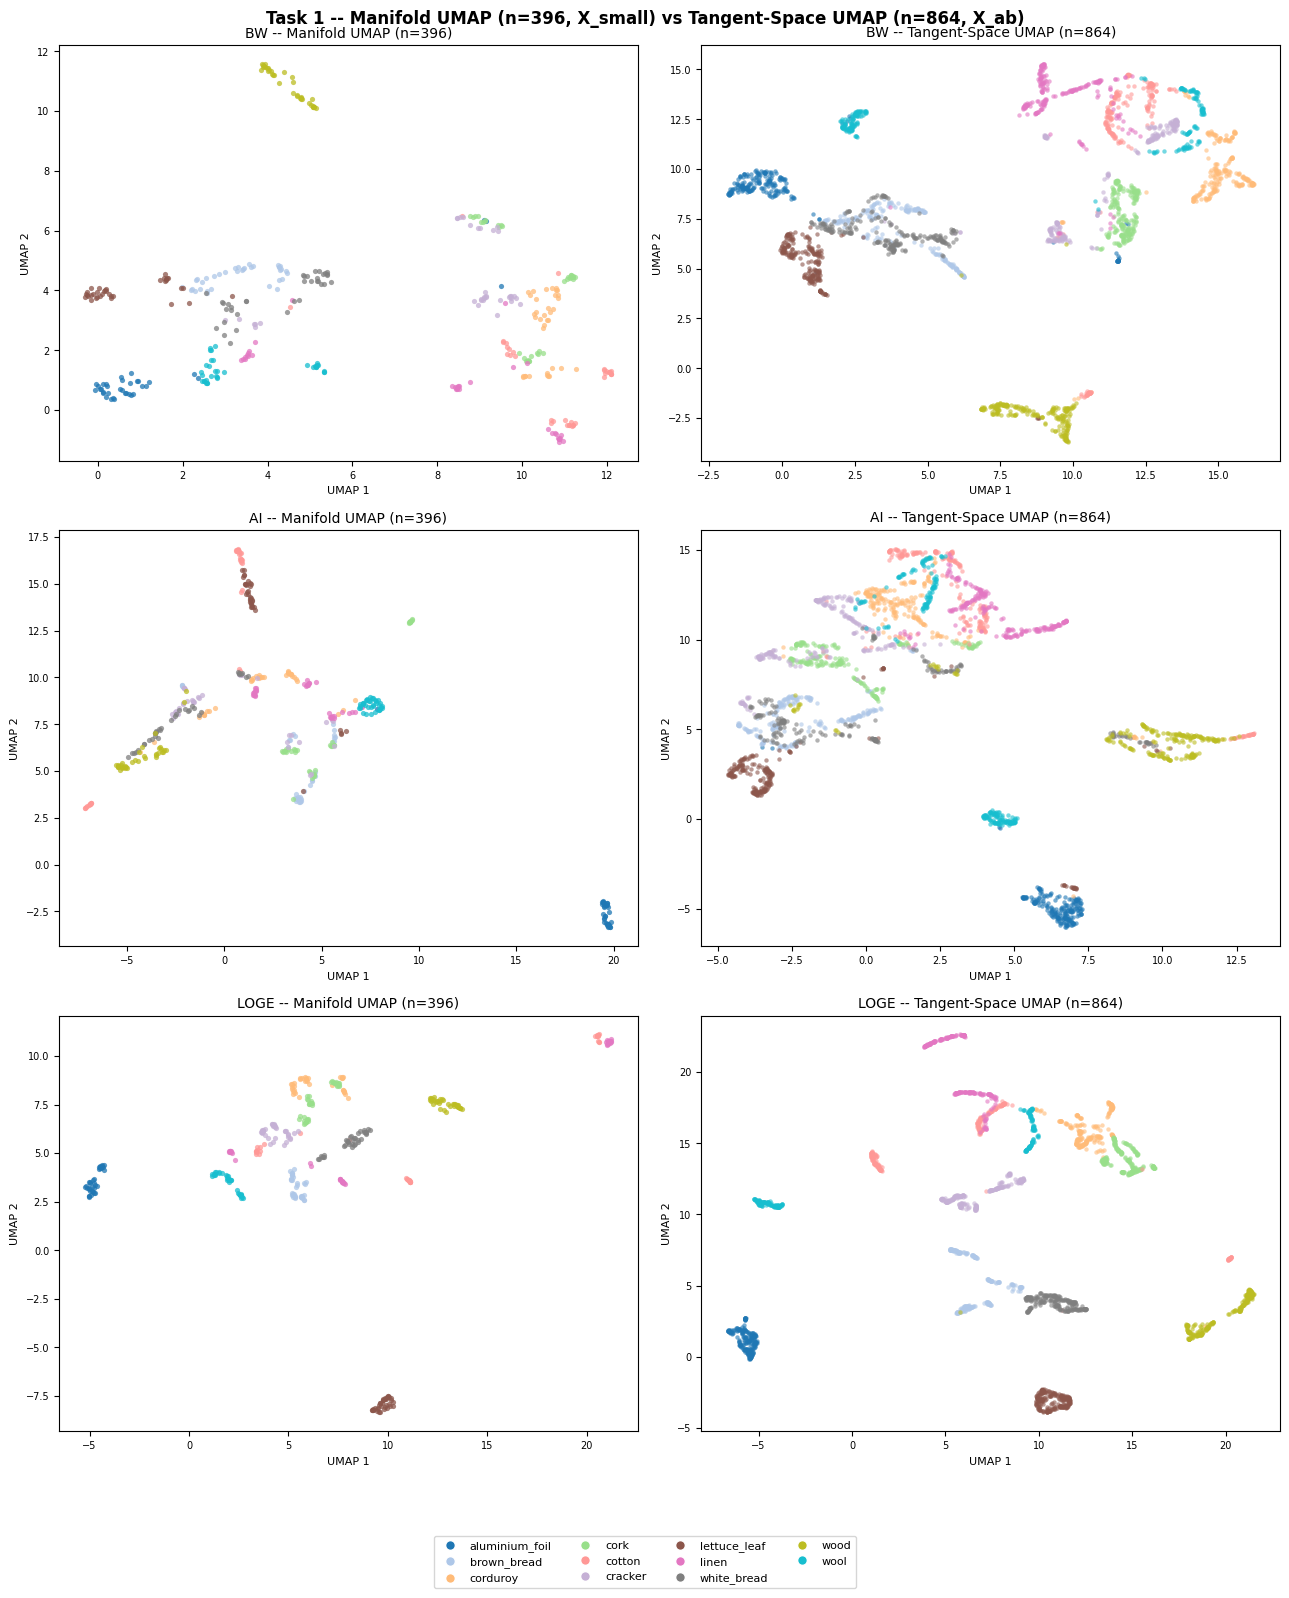

Saved: results_full_dataset/task1_umap_comparison.png


In [11]:
# Task 1 -- Plot --------------------------------------------------------------
# Left column:  Manifold UMAP    (X_small, n=396)
# Right column: Tangent-Space UMAP (X_ab,   n=864)

label_set_small = np.unique(y_small)
label_set_ab    = np.unique(y_ab)
cmap   = plt.cm.tab20
colors = {lbl: cmap(i / len(label_set_small))
          for i, lbl in enumerate(label_set_small)}

fig, axes = plt.subplots(3, 2, figsize=(13, 16))
fig.suptitle(
    "Task 1 -- Manifold UMAP (n=396, X_small) vs Tangent-Space UMAP (n=864, X_ab)",
    fontsize=12, fontweight="bold")

for row, metric in enumerate(METRICS):
    # Manifold UMAP (X_small)
    ax = axes[row, 0]
    emb = results_t1[metric]["emb_manifold"]
    for lbl in label_set_small:
        mask = y_small == lbl
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   color=colors[lbl], label=lbl, s=14, alpha=0.75, linewidths=0)
    ax.set_title(f"{metric.upper()} -- Manifold UMAP (n=396)", fontsize=10)
    ax.set_xlabel("UMAP 1", fontsize=8); ax.set_ylabel("UMAP 2", fontsize=8)
    ax.tick_params(labelsize=7)

    # Tangent-space UMAP (X_ab)
    ax = axes[row, 1]
    emb = results_t1[metric]["emb_tangent"]
    for lbl in label_set_ab:
        mask = y_ab == lbl
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   color=colors[lbl], label=lbl, s=10, alpha=0.6, linewidths=0)
    ax.set_title(f"{metric.upper()} -- Tangent-Space UMAP (n=864)", fontsize=10)
    ax.set_xlabel("UMAP 1", fontsize=8); ax.set_ylabel("UMAP 2", fontsize=8)
    ax.tick_params(labelsize=7)

handles = [plt.Line2D([0],[0], marker="o", color="w",
           markerfacecolor=colors[l], markersize=7, label=l)
           for l in label_set_small]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, -0.01), frameon=True)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(os.path.join(OUTPUT_DIR, "task1_umap_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_DIR}/task1_umap_comparison.png")


In [12]:
# Task 1 -- Neighborhood preservation metrics (X_small, n=396) ---------------
def neighborhood_overlap(D_manifold, Z_tangent, k=15):
    nn_m = NearestNeighbors(n_neighbors=k+1, metric="precomputed").fit(D_manifold)
    nn_t = NearestNeighbors(n_neighbors=k+1, metric="euclidean").fit(Z_tangent)
    _, idx_m = nn_m.kneighbors(D_manifold)
    _, idx_t = nn_t.kneighbors(Z_tangent)
    return float(np.mean([
        len(set(idx_m[i, 1:]) & set(idx_t[i, 1:])) / k
        for i in range(len(Z_tangent))
    ]))

def spearman_dist_corr(D_manifold, Z_tangent):
    n   = D_manifold.shape[0]
    tri = np.triu_indices(n, k=1)
    rho, _ = spearmanr(D_manifold[tri], pairwise_distances(Z_tangent)[tri])
    return float(rho)

K = 15
print(f"Task 1 -- Neighborhood Preservation Metrics (k={K}, X_small n=396)\n")
print(f"{'Geometry':<10}  {'Nbr Overlap':>12}  {'Trustworthiness':>16}  {'Spearman rho':>12}")
print("-" * 57)
t1_metrics = {}
for metric in METRICS:
    D       = results_t1[metric]["D"]
    Z_small = results_t1[metric]["Z_small"]
    no = neighborhood_overlap(D, Z_small, k=K)
    tw = trustworthiness(D, Z_small, n_neighbors=K, metric="precomputed")
    sp = spearman_dist_corr(D, Z_small)
    t1_metrics[metric] = {"nbr_overlap": no, "trustworthiness": tw, "spearman": sp}
    print(f"{metric.upper():<10}  {no:>12.4f}  {tw:>16.4f}  {sp:>12.4f}")


Task 1 -- Neighborhood Preservation Metrics (k=15, X_small n=396)

Geometry     Nbr Overlap   Trustworthiness  Spearman rho
---------------------------------------------------------
BW                0.8167            0.9950        0.9408
AI                0.5086            0.8490        0.6370
LOGE              0.9320            0.9995        0.9953


## Task 2 — Raw vs Standardized Tangent Features

Feature analysis runs on the **full dataset** (n=4752) to give the most representative view of feature scale and PCA variance structure.

**Q1** Boxplots of per-feature standard deviations  
**Q2** PCA cumulative variance explained — raw vs standardized

Computing barycenters and tangent features on X_full (n=4752) ...
  BW ... done (602.5s)  iters=500
  AI ... done (66.0s)  iters=4
  LOGE ... done (2.1s)  iters=0


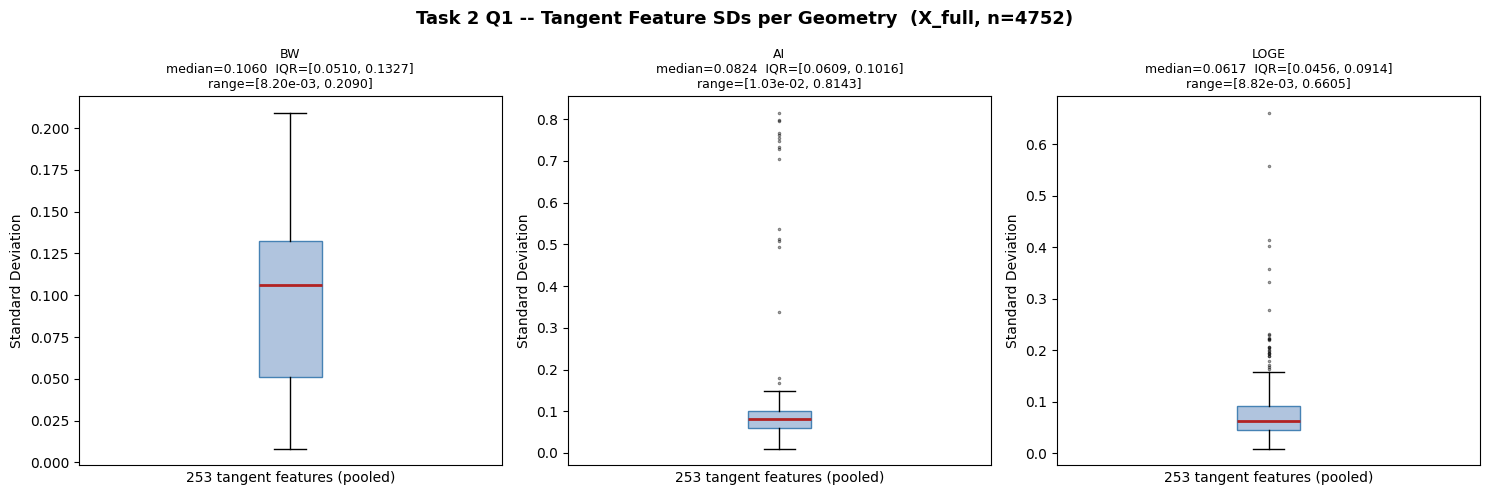

Saved: results_full_dataset/task2_feature_sds_full.png


In [13]:
# =============================================================================
# TASK 2 -- Raw vs Standardized Tangent Features  (full dataset, n=4752)
# =============================================================================
# Q1: Feature standard deviations per geometry -- computed on X_full

print("Computing barycenters and tangent features on X_full (n=4752) ...")
t2_data = {}
for metric in METRICS:
    print(f"  {metric.upper()} ...", end=" ", flush=True)
    t0 = time.time()
    M, info = compute_mean_projection(stack_npp_to_ppn(X_full), metric=metric)
    Z_full  = project_stack_to_tangent_features(X_full, M, metric=metric)
    t2_data[metric] = {"M": M, "Z": Z_full, "sds": Z_full.std(axis=0)}
    print(f"done ({time.time()-t0:.1f}s)  iters={info['iters']}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Task 2 Q1 -- Tangent Feature SDs per Geometry  (X_full, n=4752)",
             fontsize=13, fontweight="bold")
for ax, metric in zip(axes, METRICS):
    sds = t2_data[metric]["sds"]
    ax.boxplot(sds, vert=True, patch_artist=True,
               boxprops=dict(facecolor="lightsteelblue", color="steelblue"),
               medianprops=dict(color="firebrick", linewidth=2),
               flierprops=dict(marker=".", markersize=3, alpha=0.5))
    ax.set_title(
        f"{metric.upper()}\nmedian={np.median(sds):.4f}  "
        f"IQR=[{np.percentile(sds,25):.4f}, {np.percentile(sds,75):.4f}]\n"
        f"range=[{sds.min():.2e}, {sds.max():.4f}]", fontsize=9)
    ax.set_ylabel("Standard Deviation")
    ax.set_xlabel("253 tangent features (pooled)")
    ax.set_xticks([])
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task2_feature_sds_full.png"), dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR}/task2_feature_sds_full.png")


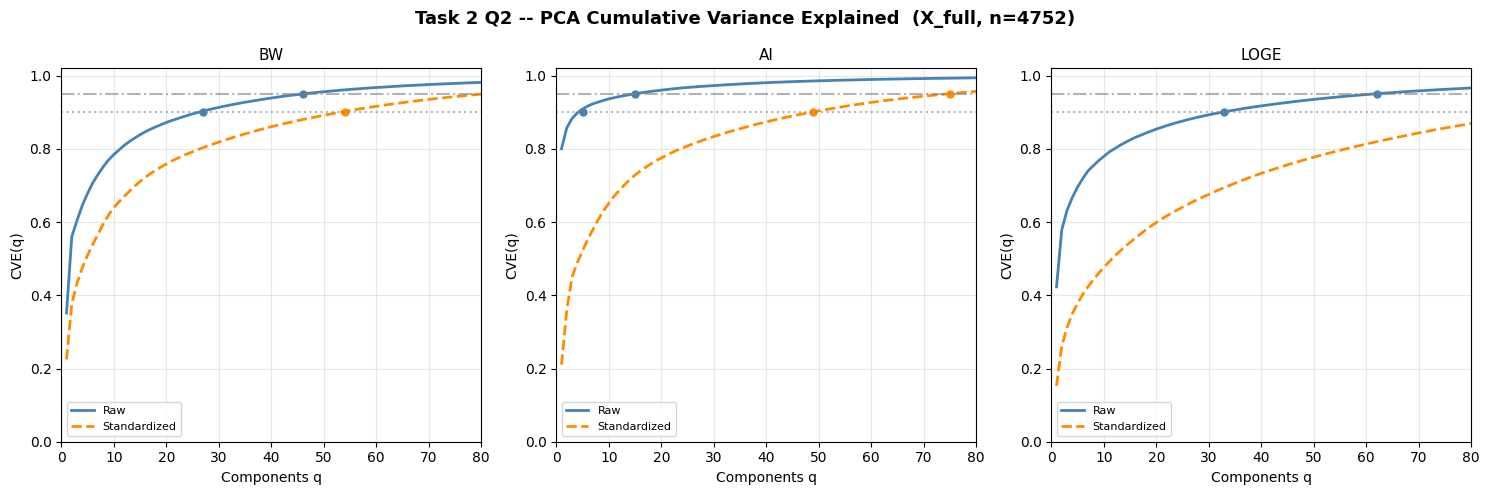

Saved: results_full_dataset/task2_pca_cve_full.png

Components needed to reach 90%/95% CVE:
Geometry   Raw@90%   Raw@95%   Std@90%   Std@95%
------------------------------------------------
BW              27        46        54        81
AI               5        15        49        75
LOGE            33        62        95       127


In [14]:
# Task 2 Q2 -- PCA CVE on X_full ---------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Task 2 Q2 -- PCA Cumulative Variance Explained  (X_full, n=4752)",
             fontsize=13, fontweight="bold")
n_feat  = 253
q_range = np.arange(1, n_feat + 1)
q_table = {}
for ax, metric in zip(axes, METRICS):
    Z_raw = t2_data[metric]["Z"]
    Z_std = StandardScaler().fit_transform(Z_raw)
    q_table[metric] = {}
    for Z, label, ls, col in [(Z_raw, "Raw", "-", "steelblue"),
                               (Z_std, "Standardized", "--", "darkorange")]:
        pca = PCA().fit(Z)
        cve = np.cumsum(pca.explained_variance_ratio_)
        ax.plot(q_range[:len(cve)], cve, ls, label=label, color=col, lw=2)
        for thresh in [0.90, 0.95]:
            idx_t = int(np.searchsorted(cve, thresh))
            if idx_t < len(cve):
                ax.plot(idx_t + 1, thresh, "o", color=col, markersize=5)
        tag = "raw" if label == "Raw" else "std"
        q_table[metric][tag] = {
            "q90": int(np.searchsorted(cve, 0.90)) + 1,
            "q95": int(np.searchsorted(cve, 0.95)) + 1,
        }
    ax.axhline(0.90, color="gray", linestyle=":", alpha=0.6)
    ax.axhline(0.95, color="gray", linestyle="-.", alpha=0.6)
    ax.set_title(f"{metric.upper()}", fontsize=11)
    ax.set_xlabel("Components q"); ax.set_ylabel("CVE(q)")
    ax.set_xlim(0, 80); ax.set_ylim(0, 1.02)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task2_pca_cve_full.png"), dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR}/task2_pca_cve_full.png\n")
print("Components needed to reach 90%/95% CVE:")
print(f"{'Geometry':<8}  {'Raw@90%':>8}  {'Raw@95%':>8}  {'Std@90%':>8}  {'Std@95%':>8}")
print("-" * 48)
for metric in METRICS:
    r = q_table[metric]["raw"]; s = q_table[metric]["std"]
    print(f"{metric.upper():<8}  {r['q90']:>8}  {r['q95']:>8}  {s['q90']:>8}  {s['q95']:>8}")


## Task 3 — Classification: 70/30 Holdout + 5-Fold CV on Full Dataset

```
X_full (n=4752)
├── 30%  held-out test set  (~1426 samples, never seen during CV)
└── 70%  training pool      (~3326 samples)
         └── 5-fold CV  (~2661 train / ~665 val per fold)
```

All preprocessing (barycenter, scaler, DR) is fitted on the **training split only** at every stage.  Results table reports:
- `cv_accuracy` ± `cv_acc_std` — mean/std over 5 folds on the 70% training pool
- `ho_accuracy` — final model (refitted on full 70%) evaluated once on the 30% holdout

**Runtime note:** BW/AI barycenters on ~2661 matrices take several minutes per fold. LogE (closed-form) is much faster. Expect total runtime of 1–4 hours for the full grid.

In [15]:
# =============================================================================
# TASK 3 -- 70/30 Holdout Split on the Full Dataset (n=4752)
# =============================================================================
#
#  X_full (n=4752)
#  ├── 30%  held-out test set  (~1426 samples, never seen during CV)
#  └── 70%  training pool      (~3326 samples)
#           └── 5-fold CV  (each fold: ~2661 train / ~665 val)
#
# All preprocessing (barycenter, scaler, DR) is fitted inside each split.
# Runtime note: BW/AI barycenters on ~2661 matrices take ~2-10 min each.
# LogE is a closed-form mean and is much faster.

X_use, y_use = X_full, y_full

le_use    = LabelEncoder()
y_enc_use = le_use.fit_transform(y_use)

X_train70, X_test30, y_train70, y_test30 = train_test_split(
    X_use, y_enc_use,
    test_size=0.30,
    stratify=y_enc_use,
    random_state=42,
)

print(f"Full dataset : {X_use.shape[0]} samples  ({len(np.unique(y_enc_use))} classes)")
print(f"Train  (70%) : {X_train70.shape[0]} samples")
print(f"Test   (30%) : {X_test30.shape[0]}  samples")
print(f"\nTrain class counts: {dict(zip(*np.unique(y_train70, return_counts=True)))}")
print(f"Test  class counts: {dict(zip(*np.unique(y_test30,  return_counts=True)))}")


Full dataset : 4752 samples  (11 classes)
Train  (70%) : 3326 samples
Test   (30%) : 1426  samples

Train class counts: {np.int64(0): np.int64(303), np.int64(1): np.int64(302), np.int64(2): np.int64(302), np.int64(3): np.int64(302), np.int64(4): np.int64(302), np.int64(5): np.int64(303), np.int64(6): np.int64(302), np.int64(7): np.int64(302), np.int64(8): np.int64(302), np.int64(9): np.int64(303), np.int64(10): np.int64(303)}
Test  class counts: {np.int64(0): np.int64(129), np.int64(1): np.int64(130), np.int64(2): np.int64(130), np.int64(3): np.int64(130), np.int64(4): np.int64(130), np.int64(5): np.int64(129), np.int64(6): np.int64(130), np.int64(7): np.int64(130), np.int64(8): np.int64(130), np.int64(9): np.int64(129), np.int64(10): np.int64(129)}


In [16]:
# Task 3 -- Shared helpers + evaluation function ------------------------------

def _make_clf(name):
    if name == "knn":
        return KNeighborsClassifier(n_neighbors=5)
    if name == "svm":
        return SVC(kernel="rbf", C=1.0, probability=True)
    if name == "lr":
        return LogisticRegression(max_iter=1000, C=1.0,
                                  solver="lbfgs", multi_class="multinomial")
    raise ValueError(f"Unknown classifier: {name}")


def _tangent_pipeline(X_tr, X_te, metric, pipeline, q, standardize, random_state):
    M, _ = compute_mean_projection(stack_npp_to_ppn(X_tr), metric=metric)
    Z_tr = project_stack_to_tangent_features(X_tr, M, metric=metric)
    Z_te = project_stack_to_tangent_features(X_te, M, metric=metric)
    if standardize:
        sc   = StandardScaler()
        Z_tr = sc.fit_transform(Z_tr)
        Z_te = sc.transform(Z_te)
    if pipeline == "B":
        n_comp = min(q, Z_tr.shape[1], Z_tr.shape[0] - 1)
        dr     = PCA(n_components=n_comp, random_state=random_state)
        Z_tr   = dr.fit_transform(Z_tr)
        Z_te   = dr.transform(Z_te)
    elif pipeline == "C":
        dr   = umap.UMAP(n_components=q, metric="euclidean",
                         n_neighbors=min(15, len(Z_tr) - 1),
                         min_dist=0.1, random_state=random_state)
        Z_tr = dr.fit_transform(Z_tr)
        Z_te = dr.transform(Z_te)
    return Z_tr, Z_te


def _collect_metrics(clf, Z_te, y_te, n_cls):
    y_pred = clf.predict(Z_te)
    acc    = accuracy_score(y_te, y_pred)
    prec   = precision_score(y_te, y_pred, average="macro", zero_division=0)
    rec    = recall_score(y_te,    y_pred, average="macro", zero_division=0)
    y_prob = (clf.predict_proba(Z_te) if hasattr(clf, "predict_proba")
              else label_binarize(y_pred, classes=np.arange(n_cls)))
    try:
        auc = roc_auc_score(y_te, y_prob, multi_class="ovr",
                            average="macro", labels=np.arange(n_cls))
    except ValueError:
        auc = float("nan")
    return acc, prec, rec, auc


def run_holdout_cv(X_train, y_train, X_test, y_test,
                   metric, pipeline="A", q=10,
                   standardize=False, classifier="knn",
                   n_cv=5, random_state=42):
    """
    Step 1 — 5-fold CV on X_train.
      Each fold fits barycenter/scaler/DR on the CV training split only.

    Step 2 — Final model.
      Barycenter/scaler/DR fitted on all of X_train.
      Evaluated once on the held-out X_test.

    Returns both CV metrics (mean over folds) and holdout metrics.
    """
    n_cls = len(np.unique(y_train))
    skf   = StratifiedKFold(n_splits=n_cv, shuffle=True, random_state=random_state)

    cv_accs, cv_precs, cv_recs, cv_aucs, cv_times = [], [], [], [], []

    for tr_idx, val_idx in skf.split(X_train, y_train):
        t0 = time.time()
        X_cv_tr,  X_cv_val  = X_train[tr_idx],  X_train[val_idx]
        y_cv_tr,  y_cv_val  = y_train[tr_idx],  y_train[val_idx]

        Z_tr, Z_val = _tangent_pipeline(X_cv_tr, X_cv_val,
                                        metric, pipeline, q, standardize, random_state)
        clf = _make_clf(classifier)
        clf.fit(Z_tr, y_cv_tr)

        acc, prec, rec, auc = _collect_metrics(clf, Z_val, y_cv_val, n_cls)
        cv_accs.append(acc);  cv_precs.append(prec)
        cv_recs.append(rec);  cv_aucs.append(auc)
        cv_times.append(time.time() - t0)

    # Final model: full training set -> holdout test
    t0 = time.time()
    Z_tr_full, Z_te_full = _tangent_pipeline(X_train, X_test,
                                              metric, pipeline, q, standardize, random_state)
    clf_final = _make_clf(classifier)
    clf_final.fit(Z_tr_full, y_train)
    h_acc, h_prec, h_rec, h_auc = _collect_metrics(clf_final, Z_te_full, y_test, n_cls)
    holdout_time = time.time() - t0

    return {
        "cv_accuracy":  np.mean(cv_accs),
        "cv_acc_std":   np.std(cv_accs),
        "cv_precision": np.mean(cv_precs),
        "cv_recall":    np.mean(cv_recs),
        "cv_auc":       np.nanmean(cv_aucs),
        "cv_runtime_s": np.sum(cv_times),
        "ho_accuracy":  h_acc,
        "ho_precision": h_prec,
        "ho_recall":    h_rec,
        "ho_auc":       h_auc,
        "ho_runtime_s": holdout_time,
    }

print("run_holdout_cv() defined.")


run_holdout_cv() defined.


In [17]:
# Task 3 -- Re-run top-5 models from holdout notebook on the full dataset -----
# Loads results_holdout/best5_configs.json and evaluates each config on
# X_train70 / X_test30 (70/30 of X_full, n=4752).
# Run this cell independently — it does NOT require the full grid to finish.

import json as _json

_configs_path = os.path.join("results_holdout", "best5_configs.json")
if not os.path.exists(_configs_path):
    raise FileNotFoundError(
        f"Could not find {_configs_path}. "
        "Run spd_geometry_holdout.ipynb through Task 3 first."
    )

with open(_configs_path) as _f:
    best5 = _json.load(_f)

_pipe_code = {"A-Full": "A", "B-PCA": "B", "C-UMAP": "C"}

print("Re-running top-5 holdout configs on X_full (n=4752, 70/30 split)\n")
print(f"{'Rk':<3}  {'Geom':<6}  {'Pipeline':<10}  {'q':>4}  {'Std':>5}  "
      f"{'Clf':<5}  {'CV_small':>8}  {'CV_full':>7}  {'HO_full':>7}")
print("-" * 68)

top5_full_rows = []
for cfg in best5:
    r = run_holdout_cv(
        X_train70, y_train70, X_test30, y_test30,
        metric      = cfg["geometry"].lower(),
        pipeline    = _pipe_code[cfg["pipeline"]],
        q           = cfg["q"] if cfg["q"] is not None else 10,
        standardize = cfg["standardize"],
        classifier  = cfg["classifier"],
    )
    top5_full_rows.append({**cfg, **{f"full_{k}": v for k, v in r.items()}})
    q_str = "--" if cfg["q"] is None else str(cfg["q"])
    print(f"  {cfg['rank']:<3}  {cfg['geometry']:<6}  {cfg['pipeline']:<10}  "
          f"{q_str:>4}  {str(cfg['standardize']):>5}  {cfg['classifier']:<5}  "
          f"{cfg['cv_accuracy']:>8.4f}  "    # CV acc from holdout nb (X_small)
          f"{r['cv_accuracy']:>7.4f}  "      # CV acc on X_full 70%
          f"{r['ho_accuracy']:>7.4f}")        # holdout acc on X_full 30%

df_top5_full = pd.DataFrame(top5_full_rows)
df_top5_full.to_csv(os.path.join(OUTPUT_DIR, "top5_on_full_dataset.csv"), index=False)
print(f"\nSaved: {OUTPUT_DIR}/top5_on_full_dataset.csv")
print("\nColumn guide:")
print("  CV_small = CV accuracy from holdout notebook (X_small n=396, 80/20)")
print("  CV_full  = CV accuracy on X_full (n=4752, 70/30, 5-fold on 70%)")
print("  HO_full  = Holdout accuracy on X_full 30% test set")


Re-running top-5 holdout configs on X_full (n=4752, 70/30 split)

Rk   Geom    Pipeline       q    Std  Clf    CV_small  CV_full  HO_full
--------------------------------------------------------------------
  1    AI      A-Full        --   True  lr       0.9779   0.9741   0.9811
  2    BW      A-Full        --   True  lr       0.9653   0.9787   0.9790
  3    LOGE    B-PCA         20  False  svm      0.9715   0.9666   0.9734
  4    LOGE    B-PCA         20   True  svm      0.9779   0.9663   0.9741
  5    LOGE    A-Full        --  False  svm      0.9937   0.9919   0.9909

Saved: results_full_dataset/top5_on_full_dataset.csv

Column guide:
  CV_small = CV accuracy from holdout notebook (X_small n=396, 80/20)
  CV_full  = CV accuracy on X_full (n=4752, 70/30, 5-fold on 70%)
  HO_full  = Holdout accuracy on X_full 30% test set


In [18]:
# Task 3 -- Run full comparison on X_full (70/30) — parallel ------------------
# Runtime estimate per geometry (parallelised across all CPU cores):
#   LogE (closed-form mean): fast  -- ~2-5 min total
#   BW   (iterative mean)  : slow  -- ~15-40 min total
#   AI   (iterative mean)  : slow  -- ~20-60 min total
# Reduce CLASSIFIERS or Q_VALUES to cut runtime if needed.
from joblib import Parallel, delayed

Q_VALUES    = [5, 10, 20]
CLASSIFIERS = ["knn", "svm", "lr"]

def single_run(X_train, y_train, X_test, y_test,
               metric, standardize, clf_name, pipe, pname, q):
    import sys, os, time as _time
    _root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
    if _root not in sys.path:
        sys.path.insert(0, _root)

    t = _time.time()
    r = run_holdout_cv(X_train, y_train, X_test, y_test,
                       metric=metric, pipeline=pipe, q=q,
                       standardize=standardize, classifier=clf_name)
    elapsed = _time.time() - t
    print(f"  done: {metric.upper()} std={standardize} {clf_name} {pname} "
          f"q={q}  cv={r['cv_accuracy']:.3f}  ho={r['ho_accuracy']:.3f}  "
          f"({elapsed:.1f}s)", flush=True)
    return {"geometry": metric.upper(), "pipeline": pname,
            "q": q, "standardize": standardize, "classifier": clf_name, **r}

# Build flat jobs list
jobs = []
for metric in METRICS:
    for standardize in [False, True]:
        for clf_name in CLASSIFIERS:
            jobs.append((metric, standardize, clf_name, "A", "A-Full", None))
            for q in Q_VALUES:
                for pipe, pname in [("B", "B-PCA"), ("C", "C-UMAP")]:
                    jobs.append((metric, standardize, clf_name, pipe, pname, q))

print(f"Total jobs: {len(jobs)} -- running in parallel (n_jobs=-1)...")
rows = Parallel(n_jobs=-1, verbose=5)(
    delayed(single_run)(X_train70, y_train70, X_test30, y_test30, *job)
    for job in jobs
)

df_results = pd.DataFrame(rows)
df_results = df_results.sort_values(
    ["geometry", "classifier", "pipeline", "q"]).reset_index(drop=True)
df_results.to_csv(os.path.join(OUTPUT_DIR, "task3_full_results.csv"), index=False)

print("\n\n-- Task 3 Results: CV (70% training) vs Holdout (30% test) --")
display_cols = ["geometry", "pipeline", "q", "standardize", "classifier",
                "cv_accuracy", "cv_acc_std", "ho_accuracy",
                "ho_precision", "ho_recall", "ho_auc"]
print(df_results[display_cols].to_string(index=False,
      float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))
print("\nSaved: task3_full_results.csv")


Total jobs: 126 -- running in parallel (n_jobs=-1)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed: 140.6min
[Parallel(n_jobs=-1)]: Done 109 out of 126 | elapsed: 192.0min remaining: 29.9min
[Parallel(n_jobs=-1)]: Done 126 out of 126 | elapsed: 193.5min finished




-- Task 3 Results: CV (70% training) vs Holdout (30% test) --
geometry pipeline       q  standardize classifier  cv_accuracy  cv_acc_std  ho_accuracy  ho_precision  ho_recall  ho_auc
      AI   A-Full     NaN        False        knn       0.9011      0.0079       0.9039        0.9105     0.9039  0.9851
      AI   A-Full     NaN         True        knn       0.9447      0.0073       0.9537        0.9549     0.9537  0.9964
      AI    B-PCA  5.0000        False        knn       0.7297      0.0120       0.7518        0.7592     0.7518  0.9487
      AI    B-PCA  5.0000         True        knn       0.7676      0.0141       0.7882        0.7900     0.7883  0.9539
      AI    B-PCA 10.0000        False        knn       0.8088      0.0084       0.8149        0.8213     0.8148  0.9649
      AI    B-PCA 10.0000         True        knn       0.8614      0.0137       0.8696        0.8718     0.8696  0.9806
      AI    B-PCA 20.0000        False        knn       0.8689      0.0088       0.8752  

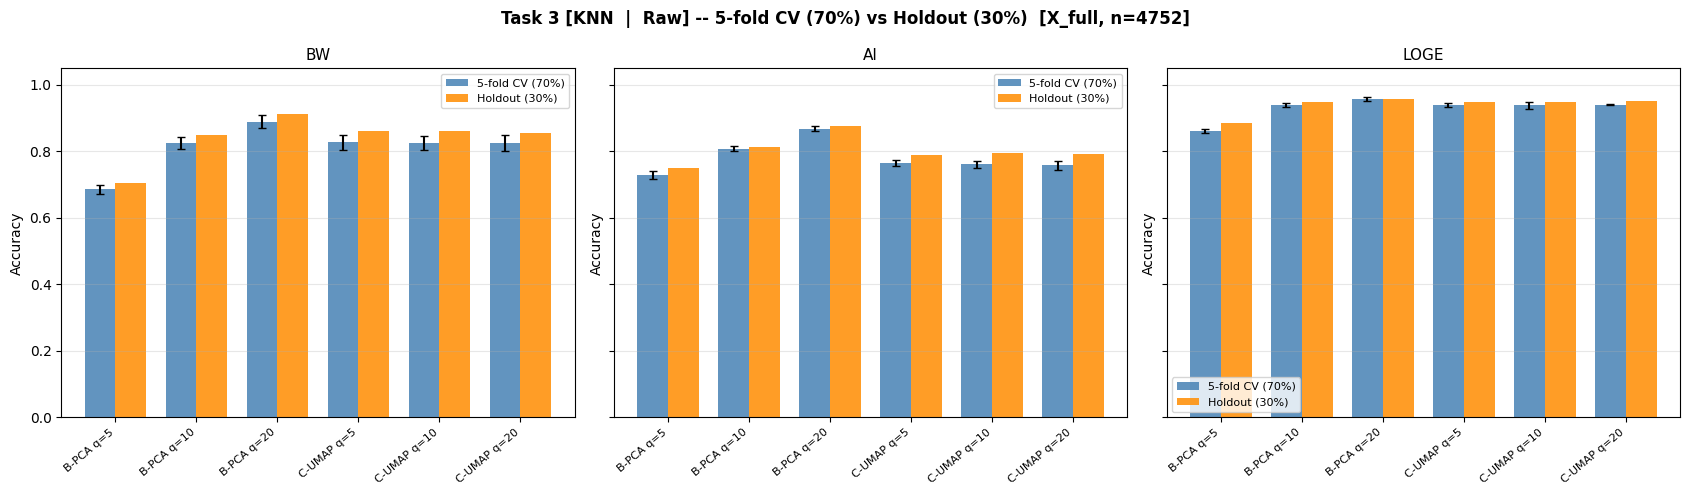

Saved: results_full_dataset/task3_full_knn_raw.png


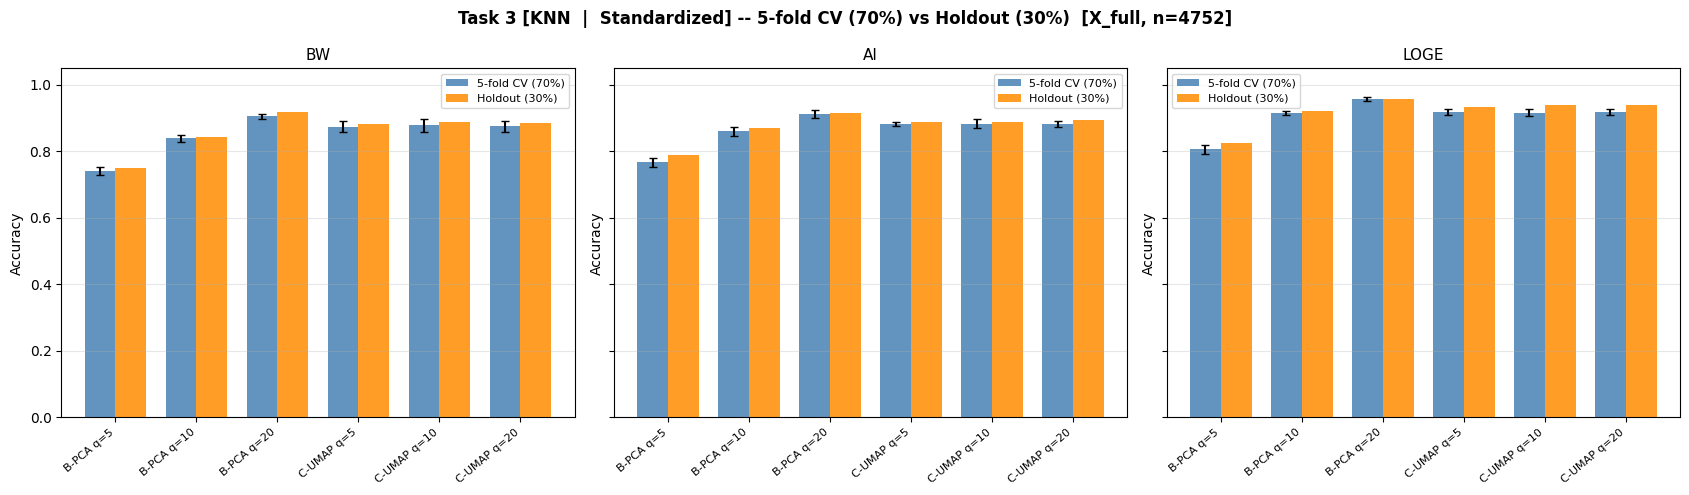

Saved: results_full_dataset/task3_full_knn_standardized.png


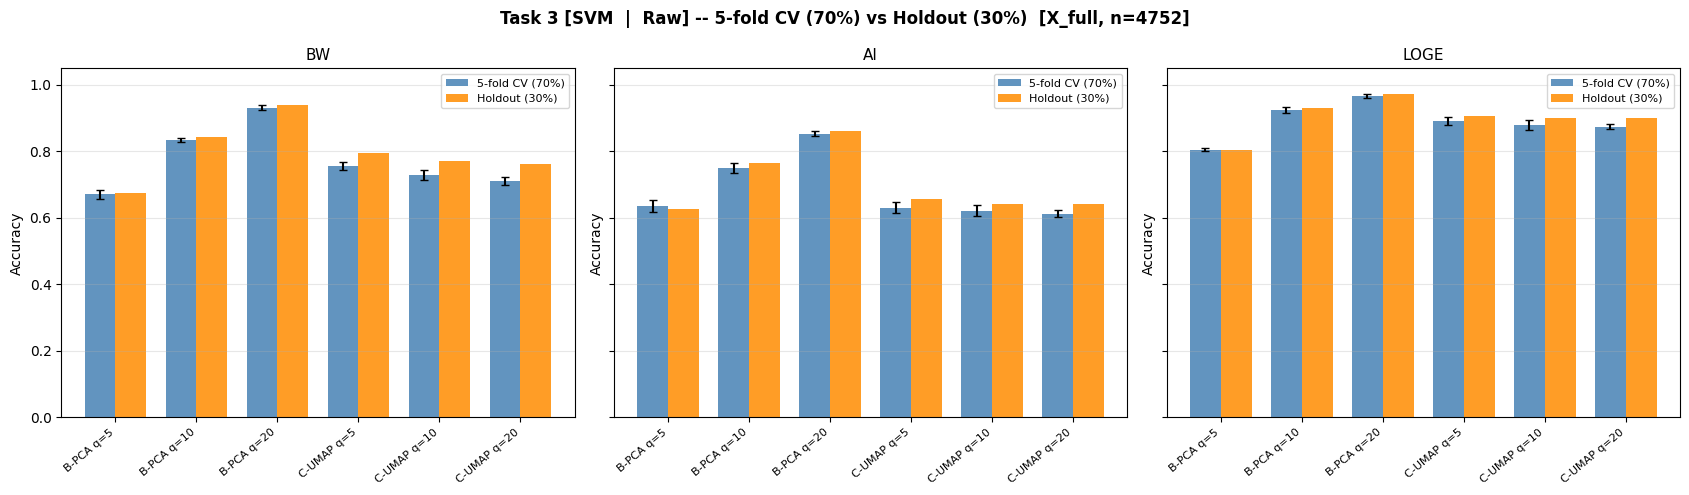

Saved: results_full_dataset/task3_full_svm_raw.png


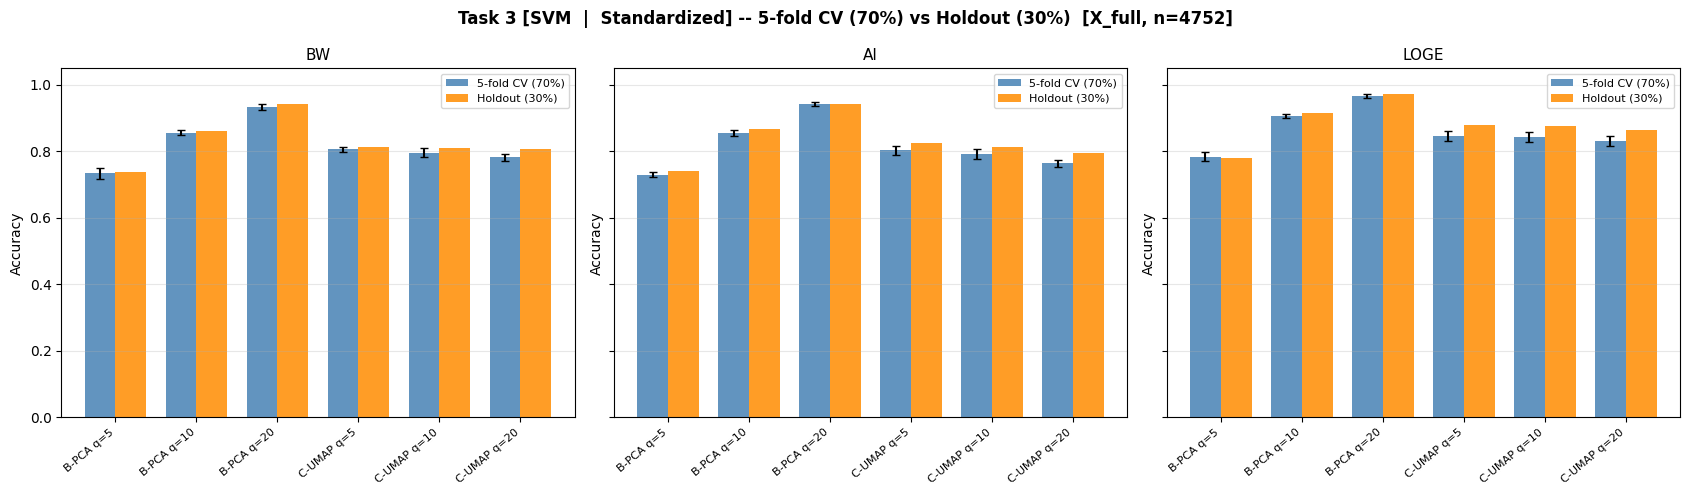

Saved: results_full_dataset/task3_full_svm_standardized.png


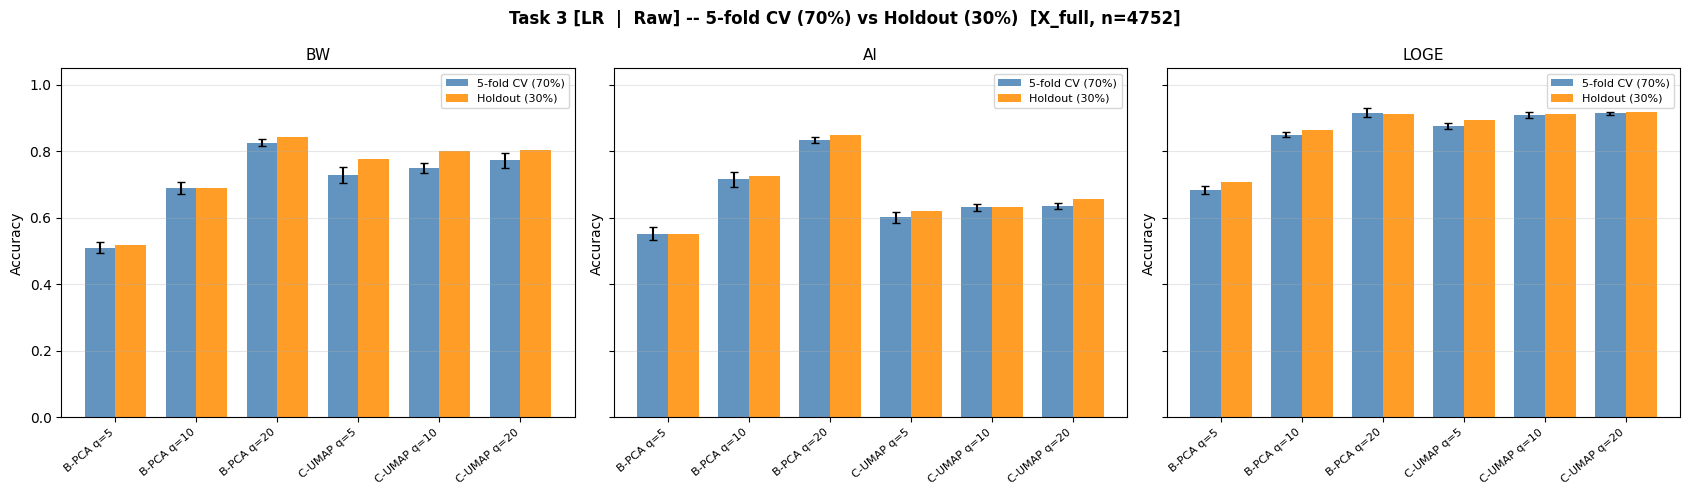

Saved: results_full_dataset/task3_full_lr_raw.png


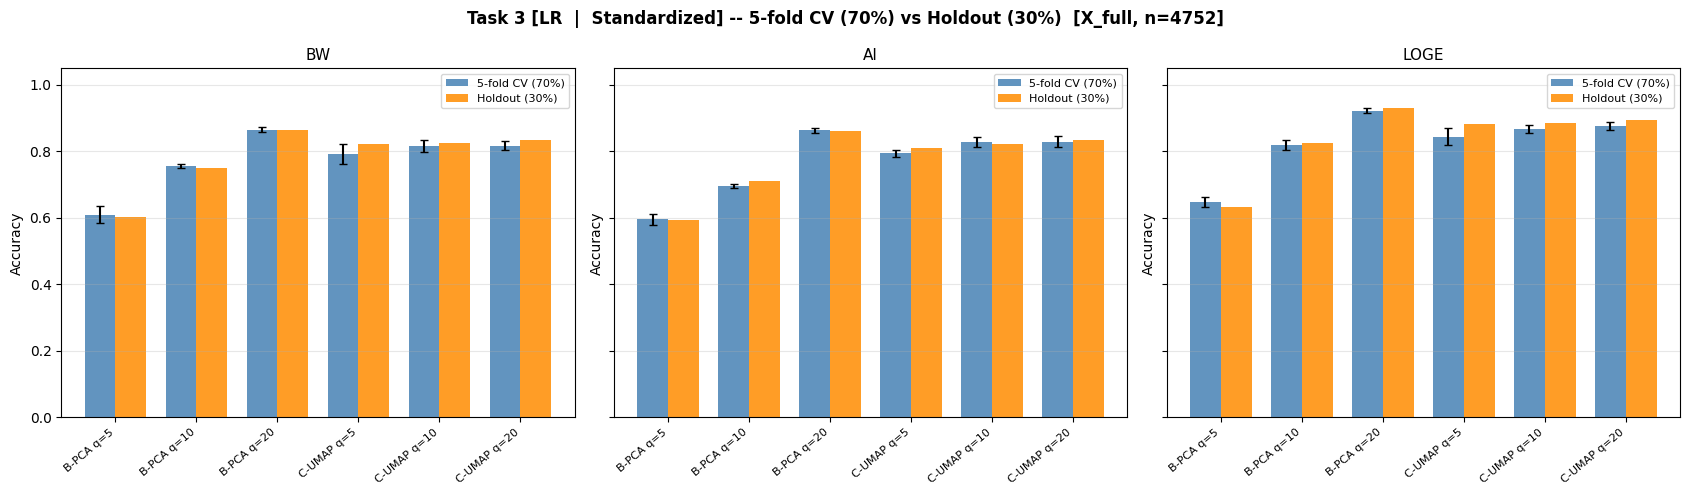

Saved: results_full_dataset/task3_full_lr_standardized.png


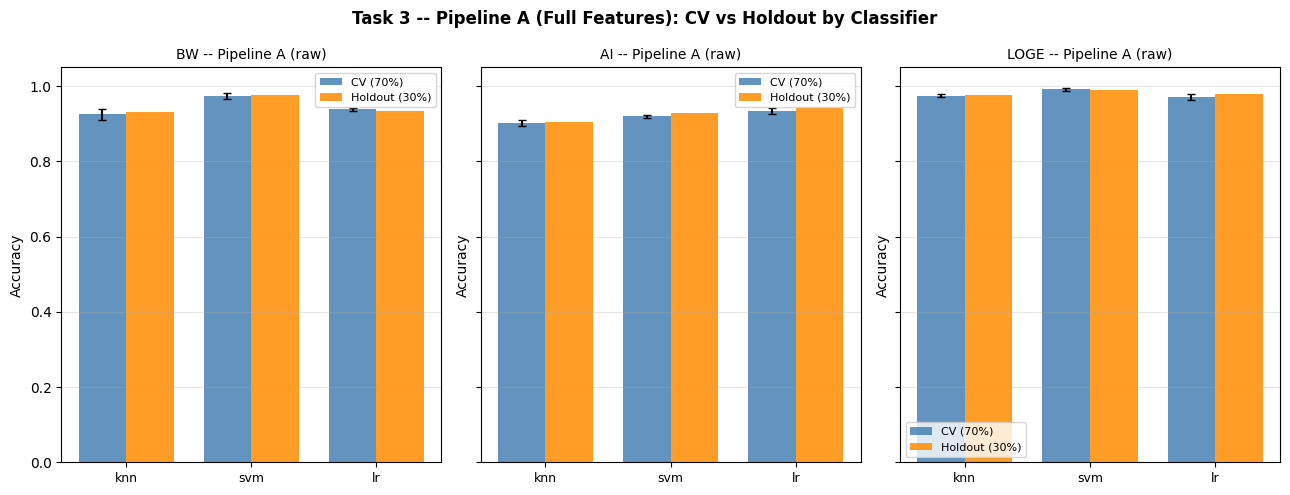

Saved: results_full_dataset/task3_full_pipelineA.png


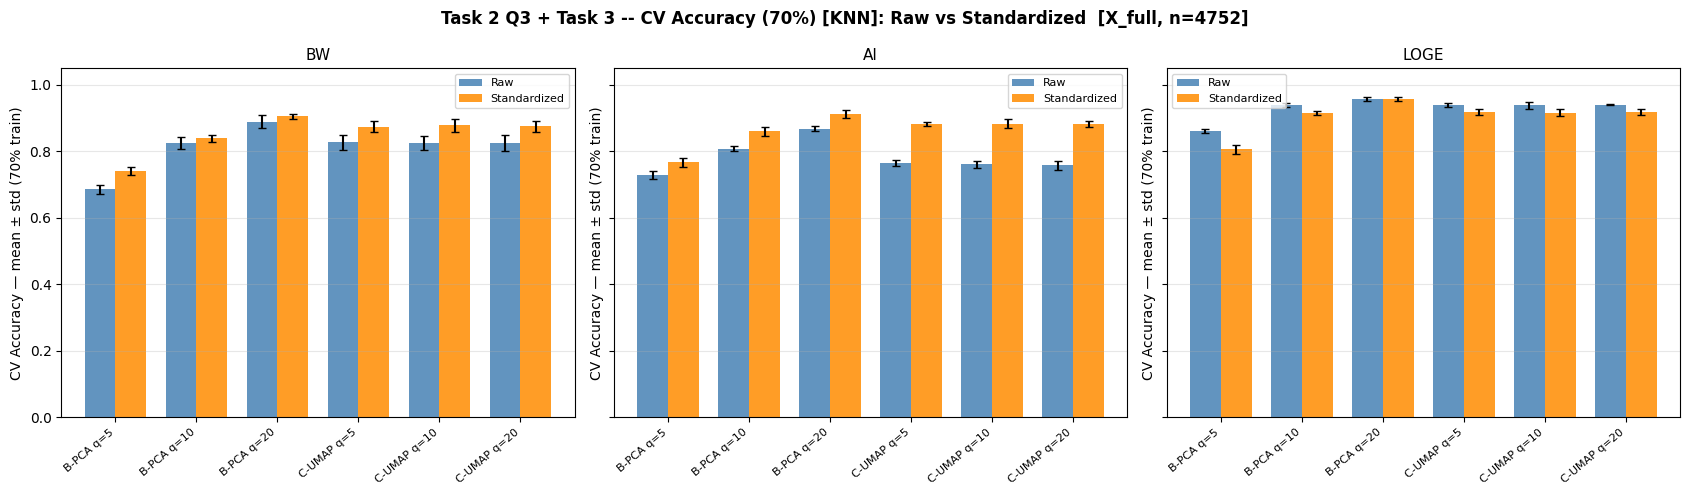

Saved: results_full_dataset/task3_full_cv_rawvsstd_knn.png


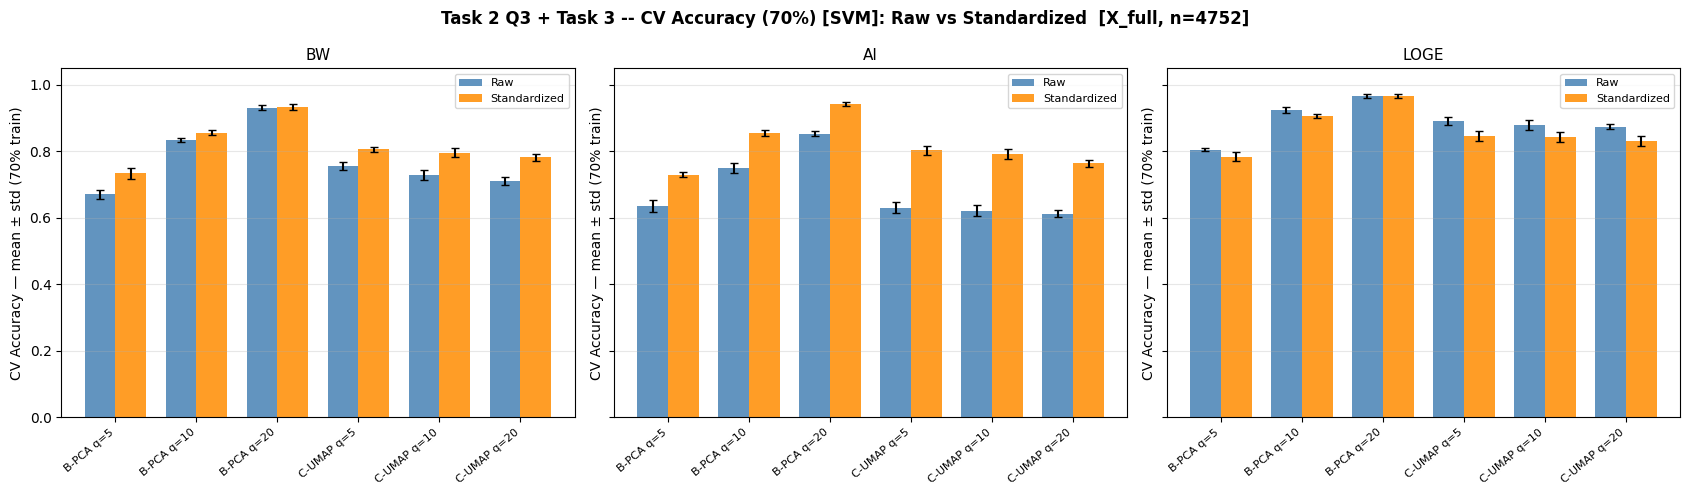

Saved: results_full_dataset/task3_full_cv_rawvsstd_svm.png


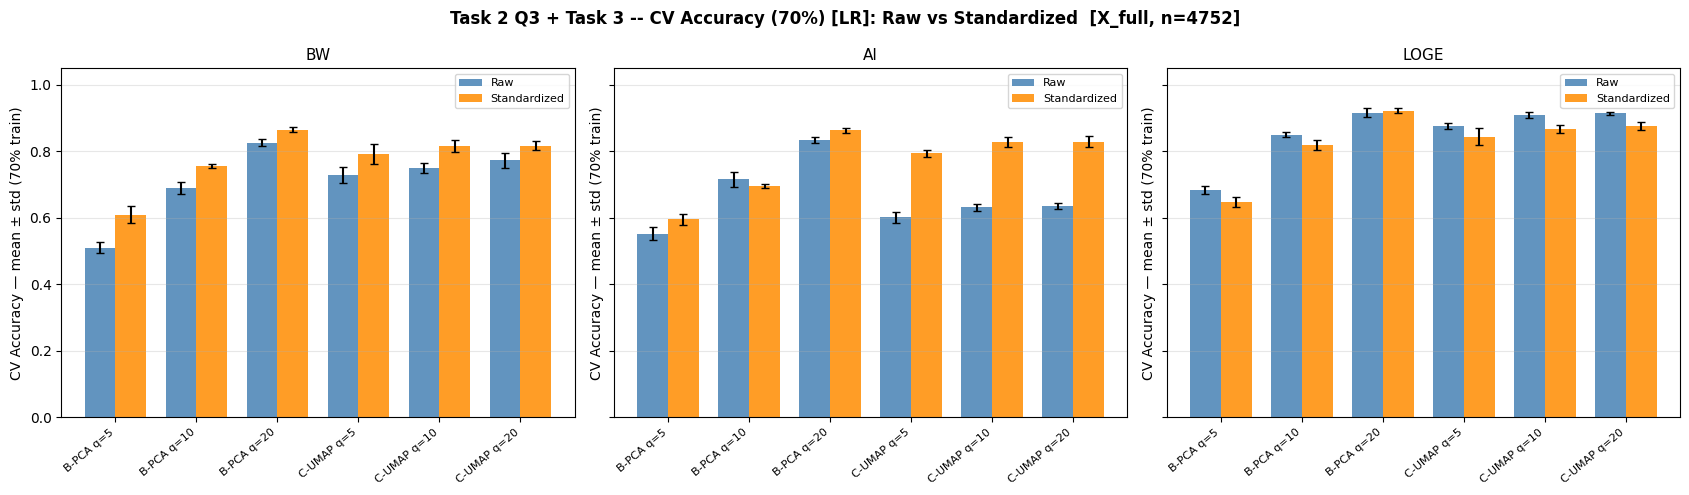

Saved: results_full_dataset/task3_full_cv_rawvsstd_lr.png


In [19]:
# Task 3 -- Plot A: CV vs Holdout accuracy ------------------------------------
# For each classifier × standardize setting: bars show 5-fold CV (70%) vs Holdout (30%)

for clf_name in CLASSIFIERS:
    df_clf = df_results[df_results["classifier"] == clf_name].copy()
    df_clf = df_clf[df_clf["pipeline"] != "A-Full"].copy()
    df_clf["label"] = df_clf.apply(
        lambda r: f"{r['pipeline']} q={int(r['q'])}", axis=1)
    label_order = [f"{pipe} q={q}"
                   for pipe in ["B-PCA", "C-UMAP"]
                   for q in Q_VALUES]

    for standardize, std_tag in [(False, "Raw"), (True, "Standardized")]:
        sub = df_clf[df_clf["standardize"] == standardize]
        if sub.empty:
            continue

        fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
        fig.suptitle(
            f"Task 3 [{clf_name.upper()}  |  {std_tag}] -- "
            f"5-fold CV (70%) vs Holdout (30%)  [X_full, n=4752]",
            fontsize=12, fontweight="bold")

        for ax, metric in zip(axes, [m.upper() for m in METRICS]):
            sub_m = sub[sub["geometry"] == metric]
            x = np.arange(len(label_order))
            w = 0.38
            cv_accs, ho_accs, cv_errs = [], [], []
            for lbl in label_order:
                row = sub_m[sub_m["label"] == lbl]
                cv_accs.append(row["cv_accuracy"].values[0] if len(row) else 0)
                cv_errs.append(row["cv_acc_std"].values[0]  if len(row) else 0)
                ho_accs.append(row["ho_accuracy"].values[0] if len(row) else 0)

            ax.bar(x - w/2, cv_accs, w, yerr=cv_errs, capsize=3,
                   label="5-fold CV (70%)", color="steelblue",  alpha=0.85)
            ax.bar(x + w/2, ho_accs, w,
                   label="Holdout (30%)",  color="darkorange", alpha=0.85)
            ax.set_xticks(x)
            ax.set_xticklabels(label_order, rotation=40, ha="right", fontsize=8)
            ax.set_title(f"{metric}", fontsize=11)
            ax.set_ylabel("Accuracy")
            ax.set_ylim(0, 1.05)
            ax.legend(fontsize=8)
            ax.grid(True, axis="y", alpha=0.3)

        plt.tight_layout()
        fname = f"task3_full_{clf_name}_{std_tag.lower()}.png"
        plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved: {OUTPUT_DIR}/{fname}")

# Pipeline A bars (full features) separately
fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True)
fig.suptitle("Task 3 -- Pipeline A (Full Features): CV vs Holdout by Classifier",
             fontsize=12, fontweight="bold")
for ax, metric in zip(axes, [m.upper() for m in METRICS]):
    sub_a = df_results[(df_results["geometry"] == metric) &
                       (df_results["pipeline"] == "A-Full") &
                       (~df_results["standardize"])]
    x = np.arange(len(CLASSIFIERS))
    w = 0.38
    cv_accs = [sub_a[sub_a["classifier"] == c]["cv_accuracy"].values[0]
               if len(sub_a[sub_a["classifier"] == c]) else 0 for c in CLASSIFIERS]
    ho_accs = [sub_a[sub_a["classifier"] == c]["ho_accuracy"].values[0]
               if len(sub_a[sub_a["classifier"] == c]) else 0 for c in CLASSIFIERS]
    cv_errs = [sub_a[sub_a["classifier"] == c]["cv_acc_std"].values[0]
               if len(sub_a[sub_a["classifier"] == c]) else 0 for c in CLASSIFIERS]
    ax.bar(x - w/2, cv_accs, w, yerr=cv_errs, capsize=3,
           label="CV (70%)",      color="steelblue",  alpha=0.85)
    ax.bar(x + w/2, ho_accs, w,
           label="Holdout (30%)", color="darkorange", alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(CLASSIFIERS, fontsize=9)
    ax.set_title(f"{metric} -- Pipeline A (raw)", fontsize=10)
    ax.set_ylabel("Accuracy"); ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8); ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task3_full_pipelineA.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_DIR}/task3_full_pipelineA.png")

# Task 3 -- Plot B: CV accuracy — Raw vs Standardized  (matches original notebook)
# For each classifier: bars show Raw vs Standardized CV accuracy across pipelines/q

for clf_name in CLASSIFIERS:
    df_clf = df_results[df_results["classifier"] == clf_name].copy()
    df_clf = df_clf[df_clf["pipeline"] != "A-Full"].copy()
    df_clf["label"] = df_clf.apply(
        lambda r: f"{r['pipeline']} q={int(r['q'])}", axis=1)
    label_order = [f"{pipe} q={q}"
                   for pipe in ["B-PCA", "C-UMAP"]
                   for q in Q_VALUES]

    fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
    fig.suptitle(
        f"Task 2 Q3 + Task 3 -- CV Accuracy (70%) [{clf_name.upper()}]: "
        f"Raw vs Standardized  [X_full, n=4752]",
        fontsize=12, fontweight="bold")

    for ax, metric in zip(axes, [m.upper() for m in METRICS]):
        sub = df_clf[df_clf["geometry"] == metric]
        x   = np.arange(len(label_order))
        w   = 0.38
        raw_accs, std_accs, raw_errs, std_errs = [], [], [], []
        for lbl in label_order:
            r = sub[(sub["label"] == lbl) & (~sub["standardize"])]
            raw_accs.append(r["cv_accuracy"].values[0] if len(r) else 0)
            raw_errs.append(r["cv_acc_std"].values[0]  if len(r) else 0)
            s = sub[(sub["label"] == lbl) & (sub["standardize"])]
            std_accs.append(s["cv_accuracy"].values[0] if len(s) else 0)
            std_errs.append(s["cv_acc_std"].values[0]  if len(s) else 0)

        ax.bar(x - w/2, raw_accs, w, yerr=raw_errs, capsize=3,
               label="Raw",          color="steelblue",  alpha=0.85)
        ax.bar(x + w/2, std_accs, w, yerr=std_errs, capsize=3,
               label="Standardized", color="darkorange",  alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(label_order, rotation=40, ha="right", fontsize=8)
        ax.set_title(f"{metric}", fontsize=11)
        ax.set_ylabel("CV Accuracy — mean ± std (70% train)")
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8)
        ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    fname = f"task3_full_cv_rawvsstd_{clf_name}.png"
    plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {OUTPUT_DIR}/{fname}")


In [20]:
# Task 3 -- Top-5 models by holdout accuracy ----------------------------------

top5 = (df_results
        .sort_values("ho_accuracy", ascending=False)
        .head(5)
        [["geometry", "pipeline", "q", "standardize", "classifier",
          "cv_accuracy", "cv_acc_std", "ho_accuracy",
          "ho_precision", "ho_recall", "ho_auc"]]
        .reset_index(drop=True))

print("=" * 72)
print("TOP-5 CONFIGURATIONS  (X_full, n=4752, 70/30 split)")
print("Ranked by holdout accuracy on the 30% test set")
print("=" * 72)
print(top5.to_string(index=True,
      float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))

# CV vs Holdout gap for top-5
print("\nCV-to-Holdout gap (positive = CV overestimates):")
for _, row in top5.iterrows():
    gap = row["cv_accuracy"] - row["ho_accuracy"]
    q_str = ("--" if (row["q"] is None or
                     (isinstance(row["q"], float) and np.isnan(row["q"])))
             else str(int(row["q"])))
    print(f"  {row['geometry']:<4} {row['pipeline']:<8} q={q_str:<3} "
          f"std={str(row['standardize']):<5} {row['classifier']:<5}  "
          f"CV={row['cv_accuracy']:.4f}  HO={row['ho_accuracy']:.4f}  "
          f"gap={gap:+.4f}")

# Save as JSON
import json as _json
best5_configs_full = []
for idx, row in top5.iterrows():
    q_val = row["q"]
    cfg = {
        "rank":         int(idx) + 1,
        "geometry":     row["geometry"],
        "pipeline":     row["pipeline"],
        "q":            None if (q_val is None or
                                  (isinstance(q_val, float) and np.isnan(q_val)))
                             else int(q_val),
        "standardize":  bool(row["standardize"]),
        "classifier":   row["classifier"],
        "cv_accuracy":  round(float(row["cv_accuracy"]),  4),
        "cv_acc_std":   round(float(row["cv_acc_std"]),   4),
        "ho_accuracy":  round(float(row["ho_accuracy"]),  4),
        "ho_precision": round(float(row["ho_precision"]), 4),
        "ho_recall":    round(float(row["ho_recall"]),    4),
        "ho_auc":       round(float(row["ho_auc"]),       4),
        "dataset":      "X_full_n4752",
        "split":        "70/30",
    }
    best5_configs_full.append(cfg)

with open(os.path.join(OUTPUT_DIR, "best5_configs_full.json"), "w") as _f:
    _json.dump(best5_configs_full, _f, indent=2)
print("\nSaved: best5_configs_full.json")


TOP-5 CONFIGURATIONS  (X_full, n=4752, 70/30 split)
Ranked by holdout accuracy on the 30% test set
  geometry pipeline   q  standardize classifier  cv_accuracy  cv_acc_std  ho_accuracy  ho_precision  ho_recall  ho_auc
0     LOGE   A-Full NaN         True         lr       0.9877      0.0047       0.9930        0.9931     0.9930  1.0000
1     LOGE   A-Full NaN        False        svm       0.9919      0.0036       0.9909        0.9910     0.9909  1.0000
2     LOGE   A-Full NaN         True        svm       0.9910      0.0041       0.9888        0.9891     0.9888  1.0000
3       AI   A-Full NaN         True        svm       0.9805      0.0042       0.9832        0.9834     0.9831  0.9998
4       AI   A-Full NaN         True         lr       0.9741      0.0062       0.9811        0.9812     0.9811  0.9998

CV-to-Holdout gap (positive = CV overestimates):
  LOGE A-Full   q=--  std=True  lr     CV=0.9877  HO=0.9930  gap=-0.0053
  LOGE A-Full   q=--  std=False svm    CV=0.9919  HO=0.9909  gap